In [73]:
import seaborn as sns
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer


In [74]:
# SimpleImputer

mean_imp = SimpleImputer(strategy='mean')
median_imp = SimpleImputer(strategy='median')
freq_imp = SimpleImputer(strategy='most_frequent')
cons_imp = SimpleImputer(strategy='constant', fill_value='Unknown')


#### Q1

In [75]:
# Load dataset

titanic = pd.DataFrame(sns.load_dataset('titanic'))
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [76]:
# Check missing values

print(f'Missing value per column: \n{titanic.isnull().sum()}')

Missing value per column: 
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [77]:
# Percentage

pct = titanic.isnull().sum() / len(titanic) * 100

print(f'Missing %: \n{pct[pct>0].sort_values(ascending=False)}')


Missing %: 
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [78]:
# Drop columns with many Nan value

titanic = titanic.drop('deck', axis='columns')

In [79]:
# Apply imputation

titanic[['age']] = median_imp.fit_transform(titanic[['age']])

titanic[['embarked','embark_town']] = freq_imp.fit_transform(titanic[['embarked','embark_town']])

In [80]:
print(f'Any missing value? \n{titanic.isnull().values.any()}')

Any missing value? 
False


#### Q2

In [81]:
# Created df with missing values

df = pd.DataFrame({
    'age':    [25, np.nan, 30, np.nan, 45, 28, np.nan],
    'salary': [50000, 60000, np.nan, 75000, np.nan, 55000, 80000],
    'score':  [np.nan, 85, 90, np.nan, 78, 92, 88]
})
df

,age,salary,score
0,25.0,50000.0,NaN
1,NaN,60000.0,85.0
2,30.0,NaN,90.0
3,NaN,75000.0,NaN
4,45.0,NaN,78.0
5,28.0,55000.0,92.0
6,NaN,80000.0,88.0


In [82]:
# Applied Mean Imputation

mean_df = pd.DataFrame(mean_imp.fit_transform(df), columns=df.columns)
print(f'Mean imputation: \n{mean_df}')


Mean imputation: 
    age   salary  score
0  25.0  50000.0   86.6
1  32.0  60000.0   85.0
2  30.0  64000.0   90.0
3  32.0  75000.0   86.6
4  45.0  64000.0   78.0
5  28.0  55000.0   92.0
6  32.0  80000.0   88.0


In [83]:
# Applied Median Imputation

median_df = pd.DataFrame(median_imp.fit_transform(df), columns=df.columns)
print(f'Median imputation: \n{median_df}')


Median imputation: 
    age   salary  score
0  25.0  50000.0   88.0
1  29.0  60000.0   85.0
2  30.0  60000.0   90.0
3  29.0  75000.0   88.0
4  45.0  60000.0   78.0
5  28.0  55000.0   92.0
6  29.0  80000.0   88.0


In [84]:
# Comparison

print(f'Before Imputation: \n{df}')

Before Imputation: 
    age   salary  score
0  25.0  50000.0    NaN
1   NaN  60000.0   85.0
2  30.0      NaN   90.0
3   NaN  75000.0    NaN
4  45.0      NaN   78.0
5  28.0  55000.0   92.0
6   NaN  80000.0   88.0


In [85]:
print(f'After Imputation(mean): \n{mean_df}')

After Imputation(mean): 
    age   salary  score
0  25.0  50000.0   86.6
1  32.0  60000.0   85.0
2  30.0  64000.0   90.0
3  32.0  75000.0   86.6
4  45.0  64000.0   78.0
5  28.0  55000.0   92.0
6  32.0  80000.0   88.0


In [86]:
print(f'After Imputation(median): \n{median_df}')

After Imputation(median): 
    age   salary  score
0  25.0  50000.0   88.0
1  29.0  60000.0   85.0
2  30.0  60000.0   90.0
3  29.0  75000.0   88.0
4  45.0  60000.0   78.0
5  28.0  55000.0   92.0
6  29.0  80000.0   88.0


#### Q3

In [87]:
# Created df with missing categorical values

cat = pd.DataFrame({
    'city':     ['Mumbai', 'Delhi', np.nan, 'Mumbai', np.nan, 'Surat'],
    'gender':   ['Male', np.nan, 'Female', 'Male', 'Female', np.nan],
    'category': [np.nan, 'Electronics', 'Clothing', np.nan, 'Electronics', 'Food']
})
cat

,city,gender,category
0,Mumbai,Male,NaN
1,Delhi,NaN,Electronics
2,NaN,Female,Clothing
3,Mumbai,Male,NaN
4,NaN,Female,Electronics
5,Surat,NaN,Food


In [88]:
# most_frequent

freq_cat = pd.DataFrame(freq_imp.fit_transform(cat), columns=cat.columns)
print(f'Most Frequent imputation: \n{freq_cat}')

Most Frequent imputation: 
     city  gender     category
0  Mumbai    Male  Electronics
1   Delhi  Female  Electronics
2  Mumbai  Female     Clothing
3  Mumbai    Male  Electronics
4  Mumbai  Female  Electronics
5   Surat  Female         Food


In [89]:
# constant

cons_cat = pd.DataFrame(cons_imp.fit_transform(cat), columns=cat.columns)
print(f'Constant Imputation: \n{cons_cat}')

Constant Imputation: 
      city   gender     category
0   Mumbai     Male      Unknown
1    Delhi  Unknown  Electronics
2  Unknown   Female     Clothing
3   Mumbai     Male      Unknown
4  Unknown   Female  Electronics
5    Surat  Unknown         Food


#### Q4

In [90]:
# Created df

city = pd.DataFrame({
    'city':['Mumbai', 'Delhi', np.nan, 'Mumbai', np.nan, 'Surat',  'Delhi', 'Mumbai', np.nan, 'Pune', np.nan],
})

In [91]:
# Most frequent

freq_city = pd.DataFrame(freq_imp.fit_transform(city), columns=city.columns)
print(f'Most Frequent imputation: \n{freq_city}')

Most Frequent imputation: 
      city
0   Mumbai
1    Delhi
2   Mumbai
3   Mumbai
4   Mumbai
5    Surat
6    Delhi
7   Mumbai
8   Mumbai
9     Pune
10  Mumbai


In [92]:
# Constant

cons_city = pd.DataFrame(cons_imp.fit_transform(city), columns=city.columns)
print(f'Constant Imputation: \n{cons_city}')

Constant Imputation: 
       city
0    Mumbai
1     Delhi
2   Unknown
3    Mumbai
4   Unknown
5     Surat
6     Delhi
7    Mumbai
8   Unknown
9      Pune
10  Unknown


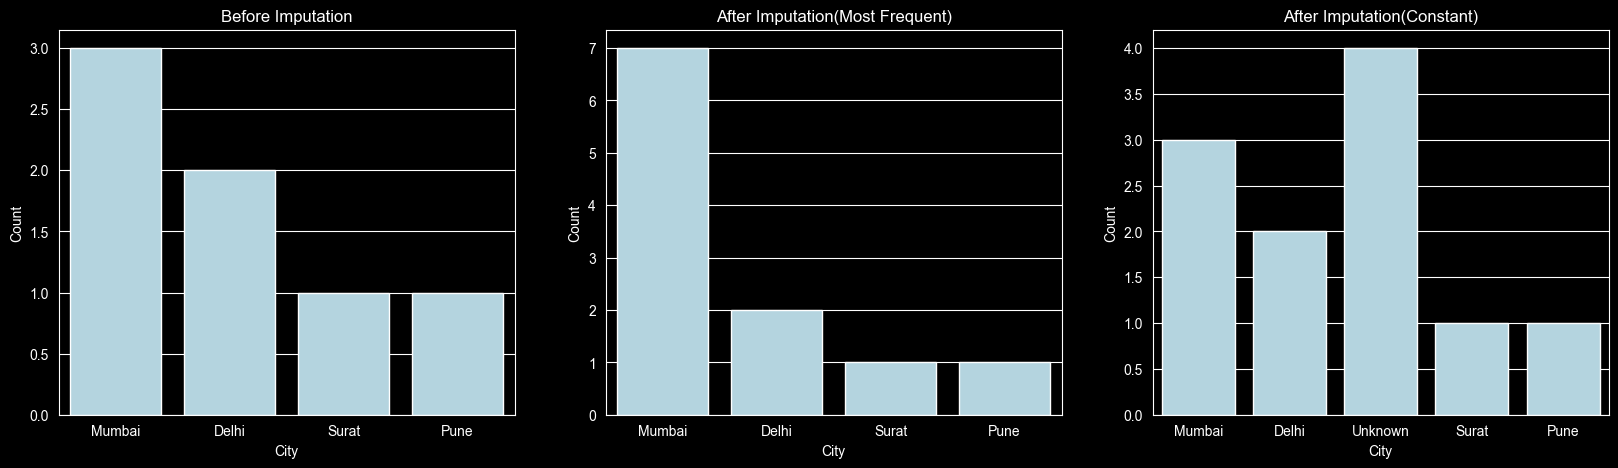

In [94]:
# Compare

flg,axes = plt.subplots(1,3,figsize=(20,5))

sns.countplot(data=city.dropna(subset='city'), x='city', ax=axes[0], color='lightblue')
axes[0].set_title('Before Imputation')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Count')

sns.countplot(data=freq_city, x='city', ax=axes[1], color='lightblue')
axes[1].set_title('After Imputation(Most Frequent)')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Count')

sns.countplot(data=cons_city, x='city', ax=axes[2], color='lightblue')
axes[2].set_title('After Imputation(Constant)')
axes[2].set_xlabel('City')
axes[2].set_ylabel('Count')

plt.show()

